Step 1 : Environment Setup

In this section, we verify the PyTorch and torchvision versions, check GPU availability, This setup ensures that the training environment is ready before loading the dataset. Using GPU will make the model train faster.



In [ ]:
# Here we are checking PyTorch and Torchvision versions as we nees to ensure compatibility with pretrained models like ResNet18 whilch will be used in this assignment
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

# Here we are confirming GPU availability
# This is important because training on GPU is significantly faster than CPU.
print("CUDA available:", torch.cuda.is_available())

# If GPU is available, the we simply print the GPU name for confirmation and easy understanding
if torch.cuda.is_available():
    print("GPU device:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cpu
Torchvision version: 0.25.0+cpu
CUDA available: False


Step 2: Mount Google Drive

we mount Google Drive so that we can store the dataset and save trained model weights. This ensures that our work persists even after the Colab session resets.

In [ ]:
# Then we have mounted Google Drive to access dataset and save model checkpoints.
# This will be way faster than uploading from local drive, that is why we chose this option


# This cell will prompt a link for authorization.
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Step 3: Dataset copying

In this step, we extract the uploaded ZIP file from Google Drive into a folder so that the dataset can be accessed for monitoring and loading. Doing this inside Colab will be faster and more reliable than unzipping locally, especially for large datasets.

In [ ]:

# 1. First we need to copy dataset (.zip) from Drive to Colab RAM
!cp "/content/drive/MyDrive/MVDIA_Practical_Assignment_Group_T/training.zip" "/content/"

# 2. The we will unzip from Colab RAM to Colab RAM
!unzip -o "/content/training.zip" -d "/content/"

Streaming output truncated to the last 5000 lines.
  inflating: /content/training/32/10656.0.jpg  
  inflating: /content/training/32/15385.2.jpg  
  inflating: /content/training/32/10746.2.jpg  
  inflating: /content/training/32/12932.2.jpg  
  inflating: /content/training/32/2278.7.jpg  
  inflating: /content/training/32/9420.4.jpg  
  inflating: /content/training/32/2564.12.jpg  
  inflating: /content/training/32/13998.20.jpg  
  inflating: /content/training/32/9984.4.jpg  
  inflating: /content/training/32/15504.166.jpg  
  inflating: /content/training/32/12550.2.jpg  
  inflating: /content/training/32/15549.7.jpg  
  inflating: /content/training/32/8502.0.jpg  
  inflating: /content/training/32/5352.3.jpg  
  inflating: /content/training/32/13152.0.jpg  
  inflating: /content/training/32/11003.1.jpg  
  inflating: /content/training/32/5355.5.jpg  
  inflating: /content/training/32/10140.2.jpg  
  inflating: /content/training/32/6501.0.jpg  
  inflating: /content/training/32/13902.3

Step 4: Verificaiton of Extracted Dataset Structure

Here, we check that the datset has been correctly unzipped from the compressed file. Now, we will list the contents of the training directory to confirm that all gesture class / folders (1–32) are there. This will help to make sure that the dataset is ready for further preprocessing.


In [ ]:
import os
print(os.listdir("/content/training"))

['14', '18', '26', '30', '32', '15', '1', '22', '16', '10', '4', '28', '13', '2', '27', '5', '29', '31', '23', '6', '3', '9', '24', '20', '7', '8', '11', '12', '19', '25', '21', '17']


Step 5: Counting Images in Each Class

In this step, we count number of images in each flass folder. This will make sure that no calss is empty and also can check if the dataset is balance or imbalanced.



In [ ]:
from glob import glob
import os

dataset_root = "/content/training"

class_folders = sorted(os.listdir(dataset_root))
image_counts = {}

for cls in class_folders:
    cls_path = os.path.join(dataset_root, cls)
    if not os.path.isdir(cls_path):
        continue

    count = (
        len(glob(os.path.join(cls_path, "*.jpg"))) +
        len(glob(os.path.join(cls_path, "*.png"))) +
        len(glob(os.path.join(cls_path, "*.jpeg")))
    )
    image_counts[cls] = count

for cls, count in image_counts.items():
    print(f"Class {cls}: {count} images")

Class 1: 104 images
Class 10: 12 images
Class 11: 2345 images
Class 12: 1403 images
Class 13: 327 images
Class 14: 347 images
Class 15: 97 images
Class 16: 163 images
Class 17: 1963 images
Class 18: 464 images
Class 19: 14 images
Class 2: 1698 images
Class 20: 4994 images
Class 21: 686 images
Class 22: 2290 images
Class 23: 3588 images
Class 24: 4025 images
Class 25: 158 images
Class 26: 3224 images
Class 27: 622 images
Class 28: 219 images
Class 29: 4618 images
Class 3: 183 images
Class 30: 57 images
Class 31: 6671 images
Class 32: 16506 images
Class 4: 634 images
Class 5: 266 images
Class 6: 191 images
Class 7: 306 images
Class 8: 2060 images
Class 9: 279 images


Step 6: Visualizing Sample Images randomly

To ensure the dataset contains valide and readable images, we select 4 random classes and display one image from each class. This will help us make sure that the images are not corrupted.



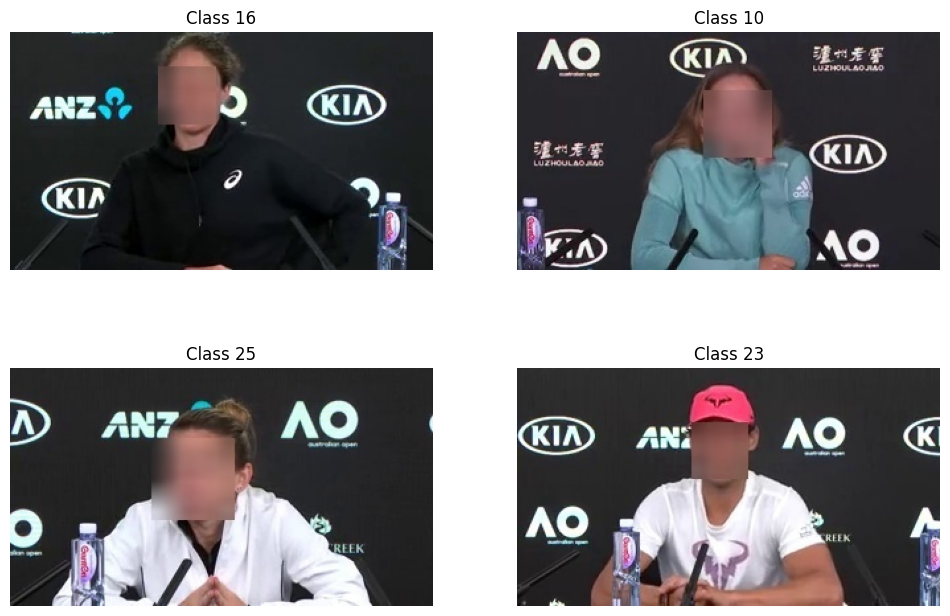

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
from glob import glob
import os

dataset_root = "/content/training"

plt.figure(figsize=(12, 8))

sample_classes = random.sample(class_folders, 4)

for i, cls in enumerate(sample_classes):
    cls_path = os.path.join(dataset_root, cls)
    sample_image = random.choice(
        glob(os.path.join(cls_path, "*.jpg")) +
        glob(os.path.join(cls_path, "*.png")) +
        glob(os.path.join(cls_path, "*.jpeg"))
    )
    img = Image.open(sample_image)

    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.title(f"Class {cls}")
    plt.axis("off")

plt.show()

Step 7: Splitting the dataset in train, validation and test part

Here, we divide the dataset into 3 subsets and subfolders: training, validation and testing. As we know, the trainsing set is used for learning the model parameter, the validation set is used to tune the hyperparameters and help prevent overfitting and the test set is used to evaluated the final model performance.
Each of these folders will contain 32 subfolders.

In [ ]:
import os, shutil, random

source_root = "/content/training/"    # Path to the original dataset (32 class folders)
dest_root = "/content/dataset_split/" # Destination folder for the split dataset

# Create the main split folders: train, val, and test
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(dest_root, split), exist_ok=True)

# These folders will only keep numeric class folders (1–32)
class_folders = [f for f in os.listdir(source_root) if f.isdigit()]
class_folders = sorted(class_folders, key=lambda x: int(x))

# Define the split ratios: 80% training, 10% validation, 10% testing
train_ratio, val_ratio = 0.8, 0.1

for cls in class_folders:
    cls_path = os.path.join(source_root, cls)

    # Create class-specific subfolders inside train/val/test folder
    for split in ["train", "val", "test"]:
        os.makedirs(os.path.join(dest_root, split, cls), exist_ok=True)

     # Shuffle images to ensure random distribution across splits
    images = os.listdir(cls_path)
    random.shuffle(images)


    total = len(images)
    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

     # Divide images according to the computed ratio
    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    # Copy training images
    for img in train_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(dest_root, "train", cls, img))

    # Copy validation images
    for img in val_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(dest_root, "val", cls, img))

    # Copy testing images
    for img in test_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(dest_root, "test", cls, img))

print("Split completed in RAM.")

Split completed in RAM.


Step 8: Checking the number of images in each split (train, validation, test).

This stage counts how many images are there in each of the three dataset splits.



In [ ]:
import os

root = "/content/dataset_split"
for split in ["train", "val", "test"]:
    total = 0
    for cls in os.listdir(os.path.join(root, split)):
        total += len(os.listdir(os.path.join(root, split, cls)))
    print(split, total)

train 48398
val 6036
test 6080


Step 9: Creating PyTorch Datasets and Dataloaders

In this stage, we convert our folder-based dataset into Pytorch-compatible dataset and dataloader objects.
We apply different image transformations for eaach split.
- Training set: includes data augmentation (random flips, rotation) to improve generalization and reduct overfitting
- Validation and test sets: use only resizing and normalization to make sure consistent evaluation.


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import WeightedRandomSampler
from collections import Counter
import torch


# Here we have defined the paths to split dataset in RAM of Google colab
train_dir = "/content/dataset_split/train"
val_dir   = "/content/dataset_split/val"
test_dir  = "/content/dataset_split/test"

# ImageNet means and standard deviations (standard for ResNet-18 model)
# The values can be found in the below source:
# https://docs.pytorch.org/vision/stable/transforms.html
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

# These transforms follow the same preprocessing method used for
# pretrained ResNet-18 (resize → center crop → tensor → normalize),
# to improve generalization during taining & validation
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])


# Transforms for validatation dataset
val_test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])


# Datasets object creation using the folder structure
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset   = datasets.ImageFolder(val_dir,   transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(test_dir,  transform=val_test_transforms)

# Here we have used the dataset's own class ordering for all evaluations
class_names = list(train_dataset.class_to_idx.keys())

# Dataloaders batch size
batch_size = 32


# Count samples per class
class_counts = Counter(train_dataset.targets)

# Compute class weights using inverse frequency
# Rare classes receive higher weights so the model treats them fairly.
class_weights = 1.0 / torch.tensor([class_counts[i] for i in range(32)], dtype=torch.float)

# Assign a weight to each sample based on class
sample_weights = [class_weights[label] for label in train_dataset.targets]

# Create sampler to ensure balanced sampling during training
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Dataloaders for training, validation, and testing
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2)

print("Datasets and dataloaders have created successfully.")
print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples:   {len(val_dataset)}")
print(f"Test samples:  {len(test_dataset)}")

Datasets and dataloaders have created successfully.
Train samples: 48398
Validation samples:   6036
Test samples:  6080


Step 10: Building the Model

Here, we create the model that will classify the 32 micro-gesture. We use transfer learning witha pretrained model ResNet-18
Then we replace the final classificaiton layer with a new layer that ouputs 32 classes. The model will be using cross-entropy loss and Adam optimizer for training.



In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch, numpy as np, random

# Here we have selected device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# To make the training results reproducible, we set all random seeds here. This ensures that the model initialization, data shuffling, and CUDA operations
# behave the same way every time we run the notebook. Without this, the model can  start from different random weights on each run, which may lead to slightly
# different training and validation results.

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Then we need to load pretrained ResNet-18
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Then we have replaced the final fully connected layer for 32 classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 32)

model = model.to(device)


from collections import Counter
import torch

# Count how many samples per class
class_counts = Counter(train_dataset.targets)

# Convert to a list ordered by class index
counts = [class_counts[i] for i in range(32)]

# Compute weights: inverse of frequency
class_weights = 1.0 / torch.tensor(counts, dtype=torch.float)

# Move weights to device
class_weights = class_weights.to(device)

# Weighted CrossEntropyLoss helps handle class imbalance by penalizing mistakes
# on underrepresented classes more strongly.
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Adam optimizer with a small learning rate and weight decay (L2 regularization)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001,weight_decay=1e-4)

# Learning rate scheduler: reduces LR when validation accuracy stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2
)


print("Model created successfully.")

Using device: cpu
Model created successfully.


Step 11 — Training the Model

Here, we train the RestNet-18 model by using the dataloader and evaluate it's performance on the train and validation set.

In this step, we train the ResNet‑18 model using the training dataloader and evaluate its performance on the validation set after each epoch. The training loop performs forward propagation, computes the loss, backpropagates gradients, and updates the model weights. Validation accuracy is monitored to track generalization and detect overfitting. The best-performing model (based on validation accuracy) is saved for later testing along with other models with different accuracy is saved also.

In [ ]:
# We are training the ResNet-18 model for 10 number of epochs.
# In each epoch, the model learns from the training data and then we check
# how well it performs on the validation set.
# We also save model from each epoch for later use

num_epochs = 10
best_val_acc = 0.0

saved_model_files = []   # store filenames for later downloading

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Training loop (now using balanced sampler + class-weighted loss)
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)   # class-weighted loss
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = correct / total
    train_loss = running_loss / total

    # Validation loop
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = val_correct / val_total

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} "
          f"Train Acc: {train_acc:.4f} "
          f"Val Acc: {val_acc:.4f}")

    scheduler.step(val_acc)

    # Saving all models individually with accuracy
    acc_str = f"{val_acc:.4f}".replace(".", "_")
    filename = f"model_epoch_{epoch+1}_acc_{acc_str}.pth"

    # Save to Google Drive
    torch.save(model.state_dict(),
               f"/content/drive/MyDrive/MVDIA_Practical_Assignment_Group_T/{filename}")

    # Save to Colab local filesystem
    torch.save(model.state_dict(), filename)

    saved_model_files.append(filename)
    print(f"Saved model for epoch {epoch+1}: {filename}")

    # Save best model separately
    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save(model.state_dict(),
                   "/content/drive/MyDrive/MVDIA_Practical_Assignment_Group_T/best_model.pth")

        torch.save(model.state_dict(), "best_model.pth")

        print("Best model updated.")

print("Training completed.")

# Download all saved models one by one
from google.colab import files

print("\nStarting downloads of all saved models\n")

for f in saved_model_files:
    files.download(f)

print("All models downloaded.")

Epoch [1/10] Train Loss: 0.2059 Train Acc: 0.5995 Val Acc: 0.2584
Saved model for epoch 1: model_epoch_1_acc_0_2584.pth
Best model updated.
Epoch [2/10] Train Loss: 0.0690 Train Acc: 0.7441 Val Acc: 0.3091
Saved model for epoch 2: model_epoch_2_acc_0_3091.pth
Best model updated.
Epoch [3/10] Train Loss: 0.0477 Train Acc: 0.7907 Val Acc: 0.3593
Saved model for epoch 3: model_epoch_3_acc_0_3593.pth
Best model updated.
Epoch [4/10] Train Loss: 0.0560 Train Acc: 0.7864 Val Acc: 0.3681
Saved model for epoch 4: model_epoch_4_acc_0_3681.pth
Best model updated.
Epoch [5/10] Train Loss: 0.0377 Train Acc: 0.8191 Val Acc: 0.3988
Saved model for epoch 5: model_epoch_5_acc_0_3988.pth
Best model updated.
Epoch [6/10] Train Loss: 0.0314 Train Acc: 0.8337 Val Acc: 0.4112
Saved model for epoch 6: model_epoch_6_acc_0_4112.pth
Best model updated.
Epoch [7/10] Train Loss: 0.0341 Train Acc: 0.8317 Val Acc: 0.4117
Saved model for epoch 7: model_epoch_7_acc_0_4117.pth
Best model updated.
Epoch [8/10] Train L

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All models downloaded.


Step 12: Running model on Internal Test dataset

Now that the model has finished training and we saved the best checkpoint along with all models from each epochs, In this step we are going to test how well the model performs on completely unseen images, which we splitted in early stage (train, val, test).

In this step, we will:
- Load the best saved model weight / we can also load the model of different accuracy saved early.
- Run the model on the test set without gradient calculations.
- Print the final test accuracy.
This gives a clear idea of how good the model is in real‑world conditions.


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# We can do this by two way, either we chose the
# best model weights saved during training from google drive OR Local drive
# we can chose any model of our choice saved / downloaded earlier
from google.colab import files
uploaded = files.upload()  # user selects best_model.pth
# Extract the filename from the uploaded dict
model_file = list(uploaded.keys())[0]
# Load the selected model weights
model.load_state_dict(torch.load(model_file, map_location=device))

model = model.to(device)
model.eval()  # we set the model to evaluation mode

# Now we will evaluate the model on the test dataset
correct = 0
total = 0

with torch.no_grad():  # we disable gradient calculation for faster testing
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)  # Forward pass
        _, predicted = torch.max(outputs, 1)  # we take the class with highest score

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# we compute the final test accuracy
test_accuracy = correct / total
print(f"Final Test Accuracy: {test_accuracy:.4f}")

Saving model_epoch_9_acc_0_4307 (1).pth to model_epoch_9_acc_0_4307 (1).pth
Final Test Accuracy: 0.4278


Step 13: Confusion Matrix for Test Dataset

At this stage, we calculate the confusion matri
Now that we have the final test accuracy, we want to understand how the model performs on each individual class. A confusion matrix shows the number of correct and incorrect predictions for every class. Each row represents the true class, it's accuracy, class with which it was mostly confused with and percentage of confusion.


In [ ]:
# Now we need to collect ground‑truth and predicted labels for the confusion matrix
y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:   # We evaluate on the test set
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        # We store the true and predicted labels for later analysis
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# We use the class order defined by ImageFolder so that
# the confusion matrix matches the dataset’s internal label mapping.
class_names = list(train_dataset.class_to_idx.keys())

import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

def simple_confusion_summary(y_true, y_pred, class_names):
    # Here we are computing the confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Then we normalize rows so each row sums to 1 (per‑class accuracy view)
    cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

    rows = []
    for i, cls in enumerate(class_names):
        # Here we are collecting accuracy exactly for this class
        correct = cm_norm[i, i]

        # For better clarification we are identifing which class this one is most confused with
        row = cm_norm[i].copy()
        row[i] = -1  # we are excluding the diagonal
        confused_with = np.argmax(row)
        confused_value = cm_norm[i, confused_with]

        # Then we are storing the summary for this class
        rows.append({
            "Class": cls,
            "Accuracy": round(correct, 2),
            "Most confused with": class_names[confused_with],
            "Confusion %": round(confused_value, 2)
        })

    df = pd.DataFrame(rows)
    df = df.reset_index(drop=True)
    return df

# Finally we are building the confusion‑matrix summary table
df_summary = simple_confusion_summary(y_true, y_pred, class_names)

from IPython.display import HTML
HTML(df_summary.to_html(index=False))

Class,Accuracy,Most confused with,Confusion %
1,1.00,10,0.00
10,1.00,1,0.00
11,0.78,12,0.09
12,0.87,14,0.06
13,0.82,12,0.06
14,0.94,20,0.03
15,0.91,7,0.09
16,0.82,12,0.06
17,0.88,2,0.03
18,0.89,16,0.02


Step 14: Per‑Class Accuracy Evaluation

While overall test accuracy provides a single performance measure for the entire model, it does not reveal how well the classifier performs on each individual gesture category. So, in this step we are going to see the accuracy per-class.


In [ ]:
import torch
import numpy as np

# We load the best model
from google.colab import files
uploaded = files.upload()  # we can selects best_model.pth or any model of our choice
model_file = list(uploaded.keys())[0]

# Load the selected model weights
model.load_state_dict(torch.load(model_file, map_location=device))
model = model.to(device)
model.eval()

# We count number of classes
num_classes = len(test_loader.dataset.classes)

# Then we have set counters for each class
correct_per_class = np.zeros(num_classes)
total_per_class = np.zeros(num_classes)

# Now we will collect predictions
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        for label, pred in zip(labels, predicted):
            total_per_class[label.item()] += 1
            if label.item() == pred.item():
                correct_per_class[label.item()] += 1

# And then we will compute per-class accuracy
class_names = test_loader.dataset.classes

print("Per-Class Accuracy:")
for i in range(num_classes):
    acc = correct_per_class[i] / total_per_class[i] if total_per_class[i] > 0 else 0
    print(f"{class_names[i]}: {acc:.4f}")

Saving model_epoch_9_acc_0_4307 (1).pth to model_epoch_9_acc_0_4307 (1) (1).pth
Per-Class Accuracy:
1: 1.0000
10: 1.0000
11: 0.7787
12: 0.8723
13: 0.8235
14: 0.9444
15: 0.9091
16: 0.8235
17: 0.8782
18: 0.8936
19: 1.0000
2: 0.7427
20: 0.2340
21: 0.7571
22: 0.7424
23: 0.6583
24: 0.8486
25: 1.0000
26: 0.8390
27: 0.8889
28: 0.8261
29: 0.2333
3: 1.0000
30: 0.8571
31: 0.1572
32: 0.0157
4: 0.8906
5: 0.8571
6: 0.9500
7: 0.9375
8: 0.7233
9: 0.9310


Step 15: For external dataset, we are expected to receive a test dataset in a folder (For this case, GroupT/) containing 20,439 unlabeled test images. Our task is to load best / chosen trained model, run predictions on every image, and generate a CSV file in the required format:
filename,class


Each row must contain the exact filename and the predicted class label (1–32).


In [ ]:
# 1. First we need to copy ZIP from Drive to Colab RAM
!cp "/content/drive/MyDrive/MVDIA_Practical_Assignment_Group_T/GroupT.zip" "/content/"

# 2. The we will unzip from Colab RAM to Colab RAM
!unzip -o "/content/GroupT.zip" -d "/content/"

Archive:  /content/GroupT.zip
   creating: /content/GroupT/
  inflating: /content/GroupT/1000.1.jpg  
  inflating: /content/GroupT/10070.0.jpg  
  inflating: /content/GroupT/10116.0.jpg  
  inflating: /content/GroupT/10163.11.jpg  
  inflating: /content/GroupT/1044.8.jpg  
  inflating: /content/GroupT/10452.1.jpg  
  inflating: /content/GroupT/10498.0.jpg  
  inflating: /content/GroupT/10531.8.jpg  
  inflating: /content/GroupT/10853.2.jpg  
  inflating: /content/GroupT/10900.5.jpg  
  inflating: /content/GroupT/1113.4.jpg  
  inflating: /content/GroupT/11341.0.jpg  
  inflating: /content/GroupT/11417.1.jpg  
  inflating: /content/GroupT/11447.1.jpg  
  inflating: /content/GroupT/11448.8.jpg  
  inflating: /content/GroupT/11567.7.jpg  
  inflating: /content/GroupT/11666.0.jpg  
  inflating: /content/GroupT/11666.1.jpg  
  inflating: /content/GroupT/11670.2.jpg  
  inflating: /content/GroupT/11712.2.jpg  
  inflating: /content/GroupT/11712.3.jpg  
  inflating: /content/GroupT/11738.4.jp

In [ ]:
# Step 15: Generate CSV predictions for Final test set

import os
import csv
from PIL import Image
import torch
from torchvision import transforms, datasets
from google.colab import files


# Load the chosen model file or the best model

uploaded = files.upload()  # we selects best_model.pth or model of our choice
model_file = list(uploaded.keys())[0]

model.load_state_dict(torch.load(model_file, map_location=device))
model = model.to(device)
model.eval()

print("Model loaded successfully.")


# Load class mapping from TRAINING folder

train_root = "/content/training"
dataset = datasets.ImageFolder(train_root)
idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}

print("Class mapping loaded:", idx_to_class)


# Define transforms

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


# Folder containing test images
test_folder_path = "/content/GroupT"
group_name = os.path.basename(test_folder_path.strip("/"))


# Generate predictions and save CSV
output_csv = f"{group_name}_T.csv"
rows = []

with torch.no_grad():
    filenames = sorted(os.listdir(test_folder_path))

    for filename in filenames:
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            img_path = os.path.join(test_folder_path, filename)

            img = Image.open(img_path).convert("RGB")
            img = test_transform(img).unsqueeze(0).to(device)

            output = model(img)
            _, pred = torch.max(output, 1)

            # convert model index → real class ID
            predicted_class = idx_to_class[pred.item()]

            rows.append([filename, predicted_class])

# Write CSV
with open(output_csv, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["filename", "class"])
    writer.writerows(rows)

print(f"CSV file generated: {output_csv}")


# Download CSV
files.download(output_csv)

Saving model_epoch_9_acc_0_4307 (1).pth to model_epoch_9_acc_0_4307 (1) (3).pth
Model loaded successfully.
Class mapping loaded: {0: '1', 1: '10', 2: '11', 3: '12', 4: '13', 5: '14', 6: '15', 7: '16', 8: '17', 9: '18', 10: '19', 11: '2', 12: '20', 13: '21', 14: '22', 15: '23', 16: '24', 17: '25', 18: '26', 19: '27', 20: '28', 21: '29', 22: '3', 23: '30', 24: '31', 25: '32', 26: '4', 27: '5', 28: '6', 29: '7', 30: '8', 31: '9'}
CSV file generated: GroupT_T.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>